In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.integrate import quad
from theta_class import AMMStationaryDistributionFast
from tqdm import tqdm
from numpy.random import PCG64, Generator
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 1 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000,
}

# --- Analytical expectation via integration ---
def expected_total_fee_over_future_fast(model, mu, sigma, dt, start_step, total_step, S0, n_grid=2000, progress_bar=True):
    total_exp_fee = 0.0
    for step in tqdm(range(start_step+1, total_step+1), disable=not progress_bar):
        if step == 0:
            continue
        t = step * dt
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln = sigma * np.sqrt(t)

        # Construct the s-grid (log-space, wide enough to cover tails)
        low = np.exp(mean_ln - 5 * sd_ln)
        high = np.exp(mean_ln + 5 * sd_ln)
        s_grid = np.linspace(low, high, n_grid)

        # Evaluate fee and PDF
        fee_vals = model._expected_incoming_fee_v3(s0=s_grid)
        pdf_vals = lognorm.pdf(s_grid, s=sd_ln, scale=np.exp(mean_ln))

        # Integrate numerically
        val = np.trapezoid(fee_vals * pdf_vals, s_grid)
        total_exp_fee += val
    return total_exp_fee

# --- AMM Simulation Function ---
def run_amm_simulation(S0, n_paths, total_steps, start_step, x0, y0, mu, sigma, gamma, dt, rng=None, show_progress=False):
    """
    Optimized AMM simulation with incremental price generation.
    
    Parameters:
    -----------
    show_progress : bool
        If True, show progress bar (can be slow for large n_paths)
    """
    # --- Sample theta and compute initial S0 per path ---
    s_current = S0.copy()
    if rng is None:
        rng = Generator(PCG64(123))
    L = np.sqrt(x0 * y0)
    
    # --- Initialize inventories and fee ---
    xt = np.full(n_paths, x0, dtype=float)
    yt = np.full(n_paths, y0, dtype=float)
    total_fee_window = np.zeros(n_paths)

    # --- Pre-compute constants for performance ---
    drift_factor = (mu - 0.5 * sigma**2) * dt
    volatility_factor = sigma * np.sqrt(dt)
    one_minus_gamma = 1.0 - gamma
    gamma_over_one_minus_gamma = gamma / one_minus_gamma
    sqrt_one_minus_gamma = np.sqrt(one_minus_gamma)

    # --- Run simulation ---    
    for i in tqdm(range(1, total_steps+1), desc=f"Simulation {total_steps} steps"):
        # sample z_pool
        z_pool = rng.normal(size=n_paths)
        s_current *= np.exp(drift_factor + volatility_factor * z_pool)
        
        P_AMM = yt / xt
        bid = P_AMM * one_minus_gamma
        ask = P_AMM / one_minus_gamma

        up_mask = s_current > ask 
        down_mask = s_current < bid

        if np.any(up_mask):
            s_up = s_current[up_mask]
            inv_sqrt = 1.0 / np.sqrt(one_minus_gamma * s_up)
            x_new = L * inv_sqrt
            y_new = L * sqrt_one_minus_gamma * np.sqrt(s_up)
            fee_up = gamma_over_one_minus_gamma * (y_new - yt[up_mask])
            xt[up_mask] = x_new
            yt[up_mask] = y_new
            if i > start_step:
                total_fee_window[up_mask] += fee_up

        if np.any(down_mask):
            s_down = s_current[down_mask]
            sqrt_ratio = np.sqrt(one_minus_gamma / s_down)
            x_new = L * sqrt_ratio
            y_new = L * np.sqrt(s_down / one_minus_gamma)
            fee_down = gamma_over_one_minus_gamma * (x_new - xt[down_mask]) * s_down
            xt[down_mask] = x_new
            yt[down_mask] = y_new
            if i > start_step:
                total_fee_window[down_mask] += fee_down

    # --- Simulation stats ---
    sim_mean_fee = np.mean(total_fee_window)
    sim_std_fee = np.std(total_fee_window)
    
    return sim_mean_fee, sim_std_fee, total_fee_window


# --- Plotting Function ---
def plot_fee_comparison(total_fee_window, sim_mean_fee, sim_std_fee, analytical_exp_fee, 
                       static_multiple_step_fee, naive_multiple_step_fee, start_step, total_steps):
    plt.figure(figsize=(8, 5))
    plt.hist(total_fee_window, bins=60, color="lightblue", edgecolor="k", density=True)
    plt.axvline(sim_mean_fee, color="r", linestyle="--", label=f"Sim mean: {sim_mean_fee:.3e}, std: {sim_std_fee:.3e}")
    plt.axvline(sim_mean_fee + sim_std_fee, color="gray", linestyle=":")
    plt.axvline(sim_mean_fee - sim_std_fee, color="gray", linestyle=":")
    plt.axvline(analytical_exp_fee, color="g", linestyle="-", linewidth=2,
                label=f"Analytical: {analytical_exp_fee:.3e}")
    plt.axvline(static_multiple_step_fee, color="y", linestyle="--", linewidth=2,
                label=f"Static: {static_multiple_step_fee:.3e}")
    plt.axvline(naive_multiple_step_fee, color="blue", linestyle="-", linewidth=2,
                label=f"Naive: {naive_multiple_step_fee:.3e}")
    plt.legend()
    plt.xlabel(f"Total fee accumulated from step {start_step} → {total_steps}")
    plt.ylabel("Density")
    plt.title("Monte Carlo vs Analytical Expected Fee Comparison")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()


# --- Combined Simulation + Integration Comparison ---
def compare_simulation_and_integration(total_steps, start_step, params, sim=True, plot=False, progress_bar=False):
    """
    Run GBM AMM simulation for total_steps and accumulate fees
    from start_step to total_steps.
    Compare simulation mean/std vs. integral-based expectation.
    """

    # --- Unpack params ---
    x0, y0, mu, sigma, gamma, dt, n_paths = (
        params["x0"], params["y0"], params["mu"],
        params["sigma"], params["gamma"], params["dt"],
        params["n_paths"]
    )

    # --- Build stationary theta model ---
    bins = np.linspace(-1.0, 1.0, params["N_bins"])
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    model = AMMStationaryDistributionFast(
        gamma=gamma, mu=mu, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers
    )
    rng = Generator(PCG64(123))
    theta_list = np.concatenate([model.bin_centers, [-1.0, 1.0]])
    pi = model.pi_star / model.pi_star.sum()
    theta_samples = rng.choice(theta_list, size=n_paths, p=pi)
    S0 = (y0 / x0) * np.power(1.0 - gamma, -theta_samples)
    if sim:
        sim_mean_fee, sim_std_fee, total_fee_window = run_amm_simulation(
            S0, n_paths, total_steps, start_step, x0, y0, mu, sigma, gamma, dt
        )

    # --- Analytical expectation ---
    analytical_exp_fee = expected_total_fee_over_future_fast(
        model, mu, sigma, dt, start_step, total_steps, S0=1.0, progress_bar=progress_bar
    )
    static_multiple_step_fee = model._expected_incoming_fee_vec() * (total_steps - start_step)
    naive_multiple_step_fee = model._incoming_fee_vec(theta=0.0) * (total_steps - start_step)

    if sim and plot:
        plot_fee_comparison(
            total_fee_window, sim_mean_fee, sim_std_fee, analytical_exp_fee,
            static_multiple_step_fee, naive_multiple_step_fee, start_step, total_steps
        )
    if sim:
        return sim_mean_fee, sim_std_fee, analytical_exp_fee, static_multiple_step_fee, naive_multiple_step_fee
    else:
        return analytical_exp_fee, static_multiple_step_fee, naive_multiple_step_fee



### Key Results 

In [26]:
import pandas as pd

params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 10,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 1_000_000,
}

x0, y0, mu, sigma, gamma, dt, n_paths = (
    params["x0"], params["y0"], params["mu"],
    params["sigma"], params["gamma"], params["dt"],
    params["n_paths"]
)

bins = np.linspace(-1.0, 1.0, params["N_bins"])
bin_centers = 0.5 * (bins[:-1] + bins[1:])
model = AMMStationaryDistributionFast(
    gamma=gamma, mu=mu, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers
)
rng = np.random.default_rng(123)
theta_list = np.concatenate([model.bin_centers, [-1.0, 1.0]])
pi = model.pi_star / model.pi_star.sum()
theta_samples = rng.choice(theta_list, size=n_paths, p=pi)
S0 = (y0 / x0) * np.power(1.0 - gamma, -theta_samples)
print(f"Initial S0 generated successfully, starting simulation...")
results = []

for tot in tqdm(np.arange(10000, 5_000_001, 10000)):
    total_steps = tot
    start_step = total_steps - 1
    ana, stat, naiv = compare_simulation_and_integration(
        total_steps, start_step, params, sim=False, plot=False, progress_bar=False
    )
    results.append({
        "total_steps": total_steps,
        # "sim_mean": sim_mean,
        # "sim_std": sim_std,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })

results = pd.DataFrame(results)
results.to_csv('results111.csv', index=False)


Initial S0 generated successfully, starting simulation...


100%|██████████| 500/500 [00:23<00:00, 20.98it/s]


In [33]:
import pandas as pd
import numpy as np
n_paths = 1_000_000
results = pd.read_csv('/home/shiftpub/Dynamic_AMM/results_record_100.csv')
results11 = pd.read_csv('/home/shiftpub/Dynamic_AMM/results_100_5000001.csv')
merged_df = pd.merge(results, results11, left_on='steps', right_on='total_steps', how='left')

# select first 200000 rows
# print(merged_df.head())
# merged_df = merged_df[merged_df['steps'] < 200000]
# print(merged_df.shape)
std_err = np.sqrt(merged_df['variance']) / np.sqrt(n_paths)
for col in ['ana', 'stat', 'naiv']:
    merged_df[f'{col}_std'] = (merged_df[col] - merged_df['mean']) / std_err
# print(merged_df.to_markdown())
merged_df.to_csv('simu_vs_ana_sigma_10_total_5m_interval_100.csv', index=False)

In [73]:
def plot_comparison(df, steps, n_std=3):
    import matplotlib.pyplot as plt
    plot_df = df[df['steps'] < steps]
    plt.figure(figsize=(8, 5))
    increment = plot_df['ana'].shift(1) - plot_df['ana']
    inc_of_incr = increment.shift(1) - increment
    # plt.axvline(plot_df[inc_of_incr < 0]['steps'].iloc[0], color='r', linestyle='--')
    plt.plot(plot_df['steps'], plot_df['ana'], 'o-', label='Analytical')
    plt.plot(plot_df['steps'], plot_df['stat'], 's--', label='Static')
    plt.plot(plot_df['steps'], plot_df['mean'] + n_std * np.sqrt(plot_df['variance']) / np.sqrt(n_paths), '--', label=f'Simulation CI ($+{n_std}\sigma$)')
    plt.plot(plot_df['steps'], plot_df['mean'] - n_std * np.sqrt(plot_df['variance']) / np.sqrt(n_paths), '--', label=f'Simulation CI ($-{n_std}\sigma$)')
    plt.legend()
    plt.show()

def zoom_in(df, steps, n_std=3):
    import matplotlib.pyplot as plt
    plot_df = df[df['steps'] < steps]
    plt.figure(figsize=(8, 5))
    increment = plot_df['ana'].shift(1) - plot_df['ana']
    inc_of_incr = increment.shift(1) - increment
    plt.axvline(plot_df[inc_of_incr < 0]['steps'].iloc[0], color='r', linestyle='--')
    loc = plot_df[inc_of_incr < 0]['steps'].iloc[0]
    temp_df = plot_df[(plot_df['steps'] >= loc - 5000) & (plot_df['steps'] <= loc + 5000)].copy()
    plt.plot(temp_df['steps'], temp_df['ana'], 'o-', label='Analytical')
    plt.plot(temp_df['steps'], temp_df['mean'] + n_std * np.sqrt(temp_df['variance']) / np.sqrt(n_paths), '--', label=f'Simulation CI ($+{n_std}\sigma$)')
    plt.plot(temp_df['steps'], temp_df['mean'] - n_std * np.sqrt(temp_df['variance']) / np.sqrt(n_paths), '--', label=f'Simulation CI ($-{n_std}\sigma$)')
    plt.legend()
    plt.show()
    



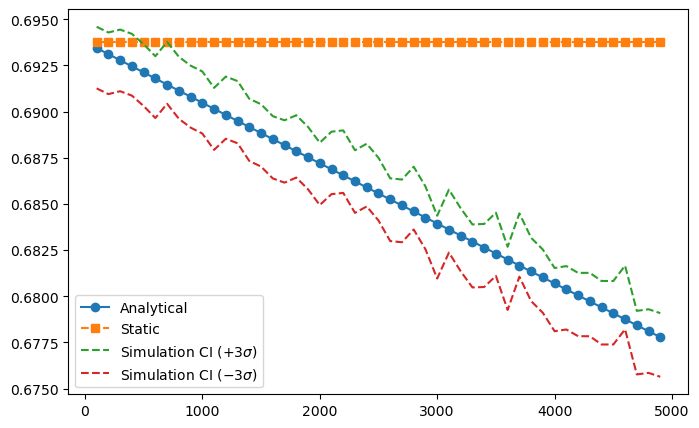

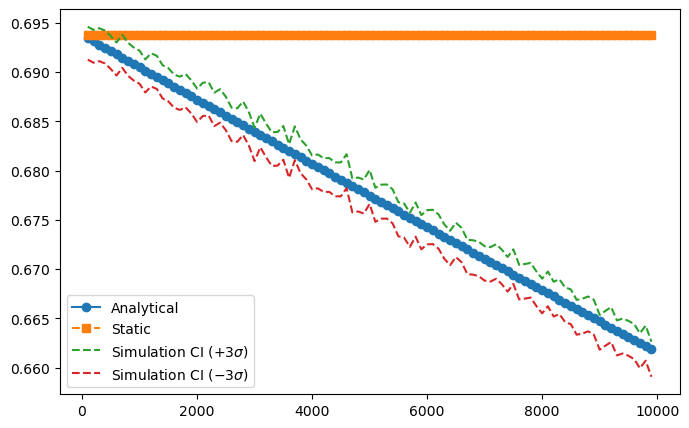

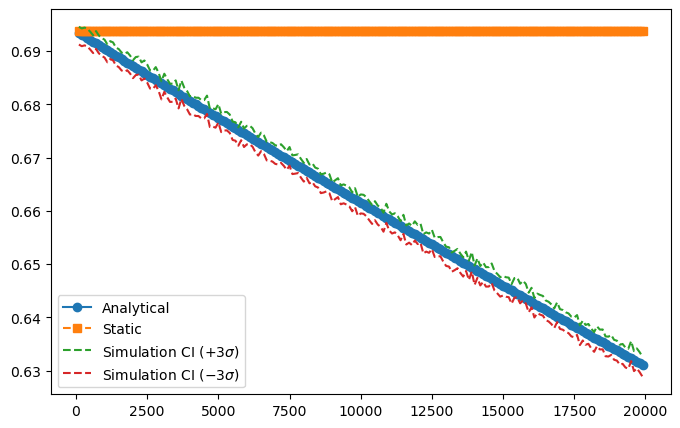

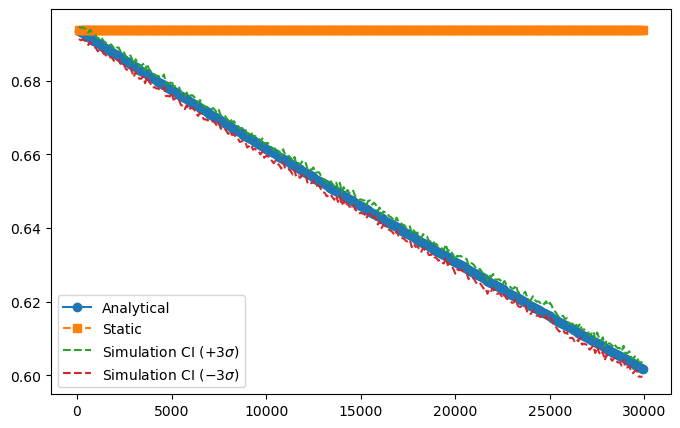

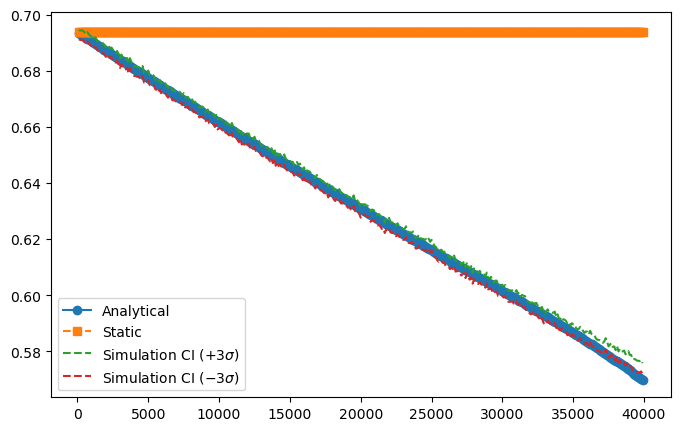

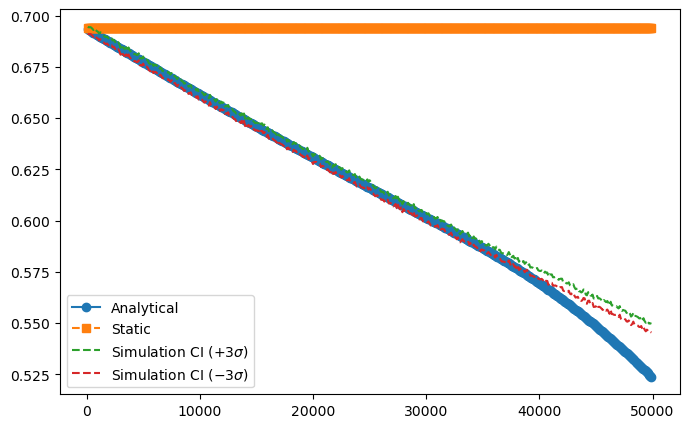

In [ ]:
total_steps = merged_df['total_steps'].max()

for steps in [5000, 10000, 20000, 30000, 40000, 50000, total_steps]:
    plot_comparison(merged_df, steps)




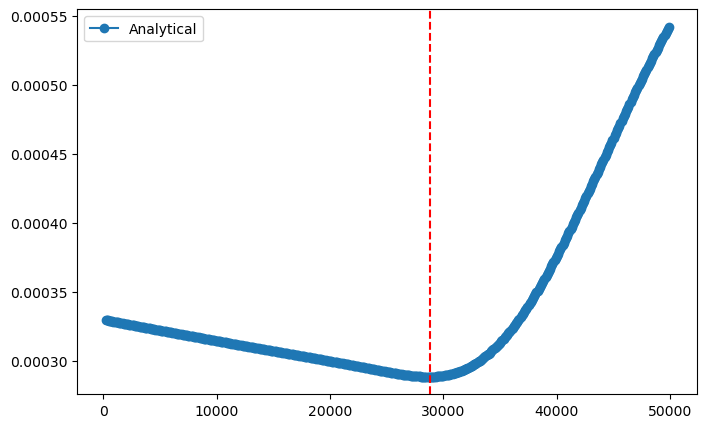

In [ ]:
def plot_comparison(df, steps, n_std=3):
    import matplotlib.pyplot as plt
    plot_df = df[df['steps'] < steps]
    plt.figure(figsize=(8, 5))
    increment = plot_df['ana'].shift(1) - plot_df['ana']
    inc_of_incr = increment.shift(1) - increment
    plt.axvline(plot_df[inc_of_incr < 0]['steps'].iloc[0], color='r', linestyle='--')
    plt.plot(plot_df['steps'], increment, 'o-', label='Analytical')
    # draw a vertical line at when increment is starting to increase
    plt.legend()
    plt.show()
    
plot_comparison(merged_df, 50000)


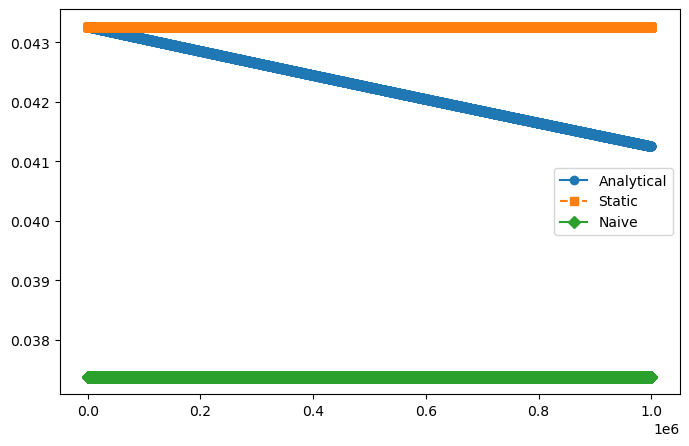

In [28]:
import pandas as pd

df = pd.read_csv('/home/shiftpub/Dynamic_AMM/results_sigma_1_100_1000001.csv')
plt.figure(figsize=(8, 5))
plt.plot(df['total_steps'], df['ana'], 'o-', label='Analytical')
plt.plot(df['total_steps'], df['stat'], 's--', label='Static')
plt.plot(df['total_steps'], df['naiv'], 'D-', label='Naive')
plt.legend()
plt.savefig('simulation_vs_analytical_sigma_1_100_1000001.png', dpi=800)
plt.show()



In [ ]:
N = int(2)
n = int(1)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True, plot=True)

In [ ]:
N = int(500)
n = int(1)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_0000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True, plot=True)

In [ ]:
N = int(5)
n = int(5)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

In [ ]:
N = int(10)
n = int(10)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

In [ ]:
N = int(100)
n = int(100)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_00000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

In [ ]:
N = int(10000)
n = int(10000)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
ana, stat, naiv = compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=False, plot=False)

print(ana, stat, naiv)

In [ ]:
# N = int(2)
from tqdm import tqdm
import pandas as pd
results = []
for N in tqdm(np.arange(1995, 2000, 5)):
    n = int(1)
    # --- Global Parameters ---
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 10,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 1_00_000,
    }
    sim, sim_std, ana, stat, naiv = compare_simulation_and_integration(total_steps=N,
                                                              start_step=N-n,
                                                              params=params,
                                                              sim=True,
                                                              plot=False,
                                                              progress_bar=False)
    results.append({
        "total_steps": N,
        "sim": sim,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })
    
results = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
plt.plot(results['total_steps'], results['sim'], 'o-', label='Simulation')
plt.plot(results['total_steps'], results['ana'], 's--', label='Analytical')
plt.plot(results['total_steps'], results['stat'], 'x-', label='Static')
plt.plot(results['total_steps'], results['naiv'], 'D-', label='Naive')
plt.legend()
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")

In [ ]:
results

In [29]:
dt = 12 / (365 * 24 * 60 * 60)
print(dt * 1000000)

0.380517503805175


In [ ]:
(0.693772 - 0.685147) / (0.5651187716124988 / np.sqrt(1_00_000))

In [ ]:
(0.6872194145123459 - 0.6878361466973647) / (0.5651187716124988 / np.sqrt(1_00_000))

In [ ]:
(0.6937723572249344 - 0.6878361466973647) / (0.5651187716124988 / np.sqrt(1_00_000))

In [ ]:
(0.6904959898732829 - 0.6885822182249637) / (0.5589501495353388/np.sqrt(1_00_000))

In [ ]:
(0.6937723572249344 - 0.6885822182249637) / (0.5589501495353388/np.sqrt(1_00_000))

In [ ]:
# N = int(2)
from tqdm import tqdm
import pandas as pd
results = []
for N in tqdm(np.arange(1, 10000000, 5000)):
    n = int(1)
    # --- Global Parameters ---
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 1,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 10_000,
    }
    ana, stat, naiv = compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=False, plot=False)
    results.append({
        "total_steps": N,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })
    
results = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
# plt.plot(results['total_steps'], results['sim'], 'o-', label='Simulation')
plt.plot(results['total_steps'], results['ana'], 's--', label='Analytical')
plt.plot(results['total_steps'], results['stat'], 'x-', label='Static')
plt.plot(results['total_steps'], results['naiv'], 'D-', label='Naive')
plt.legend()
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")

1999999 -> 20000000

1999999999 -> 

In [ ]:
# N = int(2)
from tqdm import tqdm
import pandas as pd
results = []
for N in tqdm(np.arange(500, 100000, 5000)):
    n = int(500)
    # --- Global Parameters ---
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 1,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 10_000,
    }
    ana, stat, naiv = compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=False, plot=False)
    results.append({
        "total_steps": N,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })
    
results = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
# plt.plot(results['total_steps'], results['sim'], 'o-', label='Simulation')
plt.plot(results['total_steps'], results['ana'], 's--', label='Analytical')
plt.plot(results['total_steps'], results['stat'], 'x-', label='Static')
plt.plot(results['total_steps'], results['naiv'], 'D-', label='Naive')
plt.legend()
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Storage ---
results = []

# --- Parameter sweep over N ---
for N in tqdm(np.arange(10000, 500001, 10000)):  # 500, 1000, ..., 5000
    n = 100  # accumulation window
    
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 1.0,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 10_000,
    }

    analytical_exp_fee, static_multiple_step_fee = compare_simulation_and_integration(
        total_steps=N, start_step=N - n, params=params, sim=False
    )

    results.append({
        "N": N,
        "analytical_exp_fee": analytical_exp_fee,
        "static_multiple_step_fee": static_multiple_step_fee
    })

# --- Convert to arrays for plotting ---
N_values = [r["N"] for r in results]
analytical_vals = [r["analytical_exp_fee"] for r in results]
static_vals = [r["static_multiple_step_fee"] for r in results]

# --- Plot comparison ---
plt.figure(figsize=(8, 5))
plt.plot(N_values, analytical_vals, 'o-', label='Analytical Expected Fee')
plt.plot(N_values, static_vals, 's--', label='Static Expected Fee')
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad
import time
from theta_class import AMMStationaryDistributionFast

# ============================================================
# --- Original slow version (quad integration) ---------------
# ============================================================
def expected_total_fee_over_future_quad(model, mu, sigma, dt, start_step, end_step, S0):
    total_exp_fee = 0.0
    for step in range(start_step, end_step + 1):
        t = step * dt
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln = sigma * np.sqrt(t)

        def integrand(s):
            return model._expected_incoming_fee_v2(s0=s) * lognorm.pdf(s, s=sd_ln, scale=np.exp(mean_ln))

        low = np.exp(mean_ln - 5 * sd_ln)
        high = np.exp(mean_ln + 5 * sd_ln)
        val, _ = quad(integrand, low, high, limit=200, epsabs=1e-8)
        total_exp_fee += val
    return total_exp_fee


# ============================================================
# --- Fast vectorized version (trapezoidal integration) ------
# ============================================================
def expected_total_fee_over_future_fast(model, mu, sigma, dt, start_step, end_step, S0, n_points=400):
    total_exp_fee = 0.0
    for step in range(start_step, end_step + 1):
        t = step * dt
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln = sigma * np.sqrt(t)
        s_grid = np.exp(np.linspace(mean_ln - 5 * sd_ln, mean_ln + 5 * sd_ln, n_points))
        pdf_vals = lognorm.pdf(s_grid, s=sd_ln, scale=np.exp(mean_ln))
        fee_vals = model._expected_incoming_fee_v3(s_grid)
        val = np.trapz(fee_vals * pdf_vals, s_grid)
        total_exp_fee += val
    return total_exp_fee


# ============================================================
# --- Test both methods side-by-side --------------------------
# ============================================================
def compare_integration_methods():
    # Parameters
    x0, y0 = 1e6, 1e6
    mu, sigma, gamma = 0.0, 0.2, 0.0003
    dt = 1 / (365 * 24)
    start_step, end_step = 1, 500

    # Model
    N_bins = 500
    bins = np.linspace(-1.0, 1.0, N_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt,
                                          bins=bins, bin_centers=bin_centers)

    # --- Quad version ---
    t0 = time.time()
    val_quad = expected_total_fee_over_future_quad(model, mu, sigma, dt, start_step, end_step, S0=1.0)
    t1 = time.time()

    # --- Fast vectorized version ---
    val_fast = expected_total_fee_over_future_fast(model, mu, sigma, dt, start_step, end_step, S0=1.0, n_points=400)
    t2 = time.time()

    # --- Compare results ---
    print(f"Original quad integration: {val_quad:.6e} (time: {t1 - t0:.2f}s)")
    print(f"Fast trapezoidal version:  {val_fast:.6e} (time: {t2 - t1:.2f}s)")
    print(f"Absolute diff: {abs(val_quad - val_fast):.3e}")
    print(f"Relative diff: {abs(val_quad - val_fast) / abs(val_quad):.2%}")


# ============================================================
# --- Run test ------------------------------------------------
# ============================================================
if __name__ == "__main__":
    compare_integration_methods()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu, sigma, dt, steps = 0.0, 0.2, 1/(365*24), 5000
S0 = 1.0
rng = np.random.default_rng(42)

# --- Generate GBM path ---
t = np.linspace(0, steps * dt, steps + 1)
W = np.concatenate([[0], np.cumsum(np.sqrt(dt) * rng.normal(size=steps))])
S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# --- Define accumulation window ---
start_step, end_step = 4000, 5000

plt.figure(figsize=(7, 4))
plt.plot(t, S, color="steelblue", lw=2)
plt.axvline(t[start_step], color="orange", linestyle="--", label=r"$t_{\text{start}}$")
plt.axvline(t[end_step], color="green", linestyle="--", label=r"$t_{\text{end}}$")
plt.fill_between(t[start_step:end_step+1], S[start_step:end_step+1], color="orange", alpha=0.2)
plt.xlabel("Time")
plt.ylabel("Price $S_t$")
plt.title("One GBM Path with Accumulation Window")
plt.legend()
plt.tight_layout()
plt.savefig("gbm_window.png", dpi=300)
plt.show()
